# Lecture 14.2 Object Detection

**Topic:** object detection from the problem statement to Faster R-CNN  
**Audience:** students who know CNN basics but have not yet studied boxes, IoU, or mAP in detail  
**Goal:** understand what a detector predicts, how detectors are evaluated, how Faster R-CNN works, and how to run a real example in PyTorch

This version expands the theory substantially. The notebook is designed so that a student can read it as lecture notes, not only as a sequence of code fragments.


## Outline

1. What detection predicts and why it is harder than classification  
2. Bounding-box formats, IoU, confidence scores, and NMS  
3. One-stage vs two-stage detectors  
4. Faster R-CNN architecture in detail  
5. Real dataset example with Penn-Fudan Pedestrian  
6. Practical PyTorch fine-tuning and visualization  
7. Evaluation with AP and mAP  
8. Applications, failure modes, and exercises


In [1]:
from __future__ import annotations

import math
import random
from pathlib import Path

import numpy as np

MPL_AVAILABLE = True
try:
    import matplotlib.pyplot as plt
    import matplotlib.patches as patches
except Exception as exc:
    MPL_AVAILABLE = False
    print(f"matplotlib is not available: {exc}")

PIL_AVAILABLE = True
try:
    from PIL import Image
except Exception as exc:
    PIL_AVAILABLE = False
    print(f"Pillow is not available: {exc}")

TORCH_AVAILABLE = True
try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
except Exception as exc:
    TORCH_AVAILABLE = False
    print(f"PyTorch is not available: {exc}")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

print(f"matplotlib available: {MPL_AVAILABLE}")
print(f"Pillow available: {PIL_AVAILABLE}")
print(f"PyTorch available: {TORCH_AVAILABLE}")


/usr/local/lib/python3.10/dist-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


matplotlib available: True
Pillow available: True
PyTorch available: True


## 1. What is object detection?

Object detection asks the model to solve three subproblems simultaneously:

1. determine whether an object is present  
2. classify the object  
3. localize it in the image

This is already more complex than image classification, because the output is structured. The model does not return one label. It returns a **set** of predictions, and each prediction contains:

- a bounding box  
- a class label  
- a confidence score

This means the model must reason not only about semantics, but also about geometry and multiplicity: there may be zero objects, one object, or many objects in a single image.


![Detection pipeline](images/detection_pipeline.svg)

The figure shows the broad logic: a detector turns one image into many candidate boxes, then scores and filters them. The filtering stage matters because modern detectors often produce many overlapping predictions for the same object.


## 2. Bounding boxes and coordinate formats

Boxes look simple until you start moving between datasets and libraries. Then coordinate formats become one of the most common sources of bugs.

The three formats students most often encounter are:

- `xyxy`: left, top, right, bottom  
- `xywh`: left, top, width, height  
- `cxcywh`: center x, center y, width, height

These are mathematically equivalent, but the wrong interpretation produces systematic errors:

- boxes appear shifted  
- widths become negative  
- evaluation collapses  
- visualizations look “almost right” but not quite

This is why strong practitioners always check coordinate conventions before blaming the model.


## 3. IoU, confidence, and NMS

### IoU

Intersection over Union measures the overlap between two boxes:

$$
IoU = \frac{area(Intersection)}{area(Union)}
$$

In practice, IoU is used in several places:

- matching predictions to ground truth  
- deciding whether a detection is a true positive  
- suppressing duplicate boxes

### Confidence score

A confidence score reflects how strongly the model believes the prediction is valid. In practice, the final displayed score may combine:

- objectness
- class probability
- localization quality indirectly

### NMS

Non-Maximum Suppression removes duplicate predictions. If many boxes overlap heavily, we keep the strongest one and suppress the rest.

Students should understand that NMS is not a training trick. It is part of how raw detection outputs become usable final predictions.


## 4. Why detection is more complicated to evaluate

In classification, accuracy is often enough for a first pass. Detection needs richer evaluation because we care about several things at once:

- whether the object was found  
- whether it was classified correctly  
- whether the box overlaps well enough  
- whether good detections are ranked above bad ones

This is why Average Precision (AP) and mean Average Precision (mAP) became standard. They reflect precision-recall behavior across thresholds, not just one arbitrary cutoff.


## 5. One-stage and two-stage detectors

### Two-stage detectors

Examples: Faster R-CNN, Mask R-CNN

Pipeline idea:

1. propose regions likely to contain objects  
2. classify and refine those regions

They are often accurate and conceptually clean, but usually slower.

### One-stage detectors

Examples: SSD, RetinaNet, YOLO

They predict boxes and classes directly in one pass. This often makes them faster and easier to deploy in real-time settings.

In this notebook we focus on **Faster R-CNN** because it is excellent for teaching the anatomy of a detector.


IoU = 0.32


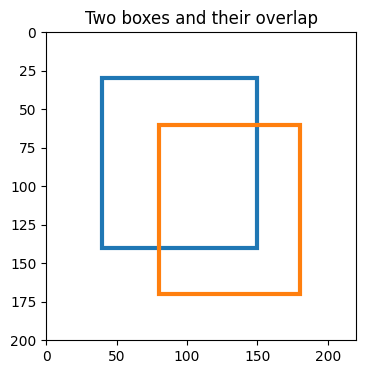

In [2]:
def box_iou_xyxy(box_a, box_b):
    xa1, ya1, xa2, ya2 = box_a
    xb1, yb1, xb2, yb2 = box_b

    inter_x1 = max(xa1, xb1)
    inter_y1 = max(ya1, yb1)
    inter_x2 = min(xa2, xb2)
    inter_y2 = min(ya2, yb2)

    inter_w = max(0, inter_x2 - inter_x1)
    inter_h = max(0, inter_y2 - inter_y1)
    inter = inter_w * inter_h

    area_a = max(0, xa2 - xa1) * max(0, ya2 - ya1)
    area_b = max(0, xb2 - xb1) * max(0, yb2 - yb1)
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


box_a = (40, 30, 150, 140)
box_b = (80, 60, 180, 170)

print("IoU =", round(box_iou_xyxy(box_a, box_b), 3))

if MPL_AVAILABLE:
    fig, ax = plt.subplots(figsize=(4, 4))
    ax.set_xlim(0, 220)
    ax.set_ylim(200, 0)
    ax.add_patch(patches.Rectangle((40, 30), 110, 110, fill=False, linewidth=3, edgecolor="tab:blue"))
    ax.add_patch(patches.Rectangle((80, 60), 100, 110, fill=False, linewidth=3, edgecolor="tab:orange"))
    ax.set_title("Two boxes and their overlap")
    plt.show()


![Faster R-CNN](images/faster_rcnn_architecture.svg)

Faster R-CNN is a very useful architecture pedagogically because each component has a clear role. It is much easier for students to understand why the system is built this way than to jump straight into a modern one-stage detector without preparation.


In [3]:
if not TORCH_AVAILABLE:
    print("PyTorch is required for the detection pipeline.")
else:
    from torchvision.datasets import PennFudanPed
    from torchvision.transforms import v2 as T

    DATA_ROOT = Path.cwd() / "data" / "pennfudan"

    image_tf = T.Compose([T.ToImage(), T.ToDtype(torch.float32, scale=True)])

    class PennFudanDetectionDataset(Dataset):
        def __init__(self, root: Path):
            self.ds = PennFudanPed(root=root, download=True)

        def __len__(self):
            return len(self.ds)

        def __getitem__(self, idx):
            image, target = self.ds[idx]
            image = image_tf(image)
            boxes = target["boxes"].float()
            labels = target["labels"].long()
            return image, {"boxes": boxes, "labels": labels}

    det_ds = PennFudanDetectionDataset(DATA_ROOT)
    print("Penn-Fudan samples:", len(det_ds))


ImportError: cannot import name 'PennFudanPed' from 'torchvision.datasets' (/usr/local/lib/python3.10/dist-packages/torchvision/datasets/__init__.py)

## 6. Faster R-CNN, stage by stage

### Backbone

A CNN extracts a feature map from the image. This feature map is the shared representation that later stages operate on.

### Region Proposal Network (RPN)

The RPN scans the feature map and proposes regions likely to contain objects. These are not final detections yet. They are candidate regions.

### ROI stage

Candidate regions are converted into fixed-size feature representations. This allows the next head to process many proposals consistently.

### Detection head

For each proposal, the head predicts:

- class scores  
- box refinements

This “proposal first, classify second” logic is why Faster R-CNN is called a two-stage detector.


## 7. Anchors and proposals

Students often hear the word “anchor” early in detection and find it mysterious. The simplest explanation is:

An anchor is a predefined candidate box shape attached to a location in the feature map.

Why use anchors?

Because the detector should not search the entire continuous box space from scratch. Anchors give it reasonable starting guesses for different scales and aspect ratios.

Even if a modern detector later uses a different assignment strategy, the general intuition remains important:

**detection needs a systematic way to connect image locations to possible boxes.**


In [ ]:
if not TORCH_AVAILABLE:
    print("Skipping detection visualization: PyTorch not available.")
else:
    image, target = det_ds[0]
    print("Image shape:", tuple(image.shape))
    print("Boxes shape:", tuple(target["boxes"].shape))

    if MPL_AVAILABLE:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(image.permute(1, 2, 0))
        for box in target["boxes"]:
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(
                patches.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=2,
                    edgecolor="red",
                )
            )
        ax.set_title("Penn-Fudan sample with ground-truth boxes")
        ax.axis("off")
        plt.show()


In [ ]:
if not TORCH_AVAILABLE:
    print("Skipping detector creation: PyTorch not available.")
else:
    from torchvision.models.detection import FasterRCNN_ResNet50_FPN_Weights, fasterrcnn_resnet50_fpn
    from torchvision.models.detection.faster_rcnn import FastRCNNPredictor

    detector = fasterrcnn_resnet50_fpn(weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT)
    in_features = detector.roi_heads.box_predictor.cls_score.in_features
    detector.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes=2)

    total_params = sum(p.numel() for p in detector.parameters())
    print("Detector parameters:", f"{total_params:,}")


## 8. Real dataset: Penn-Fudan Pedestrian

For the practical section we use Penn-Fudan Pedestrian, the same dataset used in the official `torchvision` finetuning tutorial.

Why this dataset works well for teaching:

- real street scenes  
- simple single-class problem  
- easy visual interpretation  
- small size for quick experiments

Students should notice an important difference from segmentation: the target is no longer a dense mask, but a variable-length list of boxes and labels. This changes how the dataloader and collate function must be written.


In [ ]:
if not TORCH_AVAILABLE:
    print("Skipping training step: PyTorch not available.")
else:
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    detector = detector.to(DEVICE)

    def collate_fn(batch):
        images, targets = zip(*batch)
        return list(images), list(targets)

    train_loader = DataLoader(
        torch.utils.data.Subset(det_ds, list(range(min(16, len(det_ds))))),
        batch_size=2,
        shuffle=True,
        collate_fn=collate_fn,
    )

    optimizer = torch.optim.Adam([p for p in detector.parameters() if p.requires_grad], lr=1e-4)

    detector.train()
    images, targets = next(iter(train_loader))
    images = [img.to(DEVICE) for img in images]
    targets = [{k: v.to(DEVICE) for k, v in t.items()} for t in targets]

    losses = detector(images, targets)
    total_loss = sum(losses.values())
    optimizer.zero_grad()
    total_loss.backward()
    optimizer.step()

    print("One-step training losses:")
    for name, value in losses.items():
        print(f"  {name}: {value.item():.4f}")


## 9. Why the code uses `fasterrcnn_resnet50_fpn`

This choice is practical and pedagogical.

It is practical because:

- pretrained weights exist  
- the model is part of `torchvision`  
- fine-tuning requires only a small head replacement

It is pedagogical because:

- the architecture is widely cited  
- it exposes the standard detection workflow clearly  
- students can see where the classifier and box regressor live


## 10. AP and mAP in plain language

Average Precision summarizes the precision-recall curve for one class. Mean Average Precision averages AP across classes.

Why is this better than a single score threshold?

Because detectors are ranking systems as well as localization systems. A detector that ranks true detections above false ones should be rewarded, even before we pick one fixed threshold.

This is why serious detection work is rarely evaluated with a single “accuracy”-style number.


## 11. Applications and deployment thinking

Detection is useful whenever approximate localization is enough:

- traffic analytics  
- retail shelf monitoring  
- worker safety systems  
- sports analytics  
- robotics and picking  
- wildlife and drone monitoring

In many production systems, detection is a front-end stage. A downstream tracker, counter, OCR system, or classifier consumes the detected boxes.


In [ ]:
if not TORCH_AVAILABLE:
    print("Skipping prediction demo: PyTorch not available.")
else:
    detector.eval()
    demo_image, demo_target = det_ds[1]

    with torch.no_grad():
        predictions = detector([demo_image.to(DEVICE)])[0]

    keep = predictions["scores"].cpu() > 0.5
    pred_boxes = predictions["boxes"].cpu()[keep]
    pred_scores = predictions["scores"].cpu()[keep]

    print("Predicted boxes kept after score threshold:", len(pred_boxes))

    if MPL_AVAILABLE:
        fig, ax = plt.subplots(figsize=(6, 5))
        ax.imshow(demo_image.permute(1, 2, 0))
        for box, score in zip(pred_boxes, pred_scores):
            x1, y1, x2, y2 = box.tolist()
            ax.add_patch(
                patches.Rectangle(
                    (x1, y1),
                    x2 - x1,
                    y2 - y1,
                    fill=False,
                    linewidth=2,
                    edgecolor="lime",
                )
            )
            ax.text(x1, y1 - 4, f"{score:.2f}", color="lime", fontsize=10, backgroundcolor="black")
        ax.set_title("Predictions from Faster R-CNN")
        ax.axis("off")
        plt.show()


## 12. Failure modes students should expect

Common beginner mistakes:

- using the wrong box format  
- forgetting a custom `collate_fn`  
- evaluating only visually  
- assuming low score threshold means “bad model” rather than “different precision-recall tradeoff”

Common model failure modes:

- duplicated boxes  
- missed small objects  
- poor localization under occlusion  
- boxes that drift toward background context

When debugging detectors, always inspect both:

- the raw predictions  
- the filtered predictions after thresholding and NMS


In [ ]:
# Exercise scaffold: compare score thresholds

if not TORCH_AVAILABLE:
    print("PyTorch is required for the detection exercise.")
else:
    for thr in [0.3, 0.5, 0.7]:
        keep = predictions["scores"].cpu() > thr
        print(f"threshold={thr:.1f} -> kept boxes={int(keep.sum())}")


## Exercises

1. Lower the score threshold and inspect the precision-vs-clutter tradeoff.  
2. Replace Faster R-CNN with RetinaNet or SSD and compare behavior.  
3. Convert boxes between `xyxy`, `xywh`, and `cxcywh` by hand for a few examples.  
4. Run several optimization steps instead of one and inspect how the predictions change.


## References

- Expanded from the course materials and [deepmachinelearning.ru](https://deepmachinelearning.ru/docs/Neural-networks/Object-detection).  
- Official `torchvision` object detection finetuning tutorial.  
- Faster R-CNN paper: *Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks*.
